# Zápočťák

## Specifikace

V mém statistickém projektu se budu především věnovat dynamice změny obyvatelstva na různých místech ČR. Hypotézy, které bych chtěl testovat, jsou následující:

- obyvatelstvo Královehradeckého kraje stárne – tuto hypotézu specifikuji podle toho, jak přesná data dostanu k dispozici, ale nejbezpečnější testová statistika je poměr lidí nad 65 let vůči zbytku
- poměr počtu obyvatel okolí Prahy a počtu obyvatel v Praze roste (podobnou statistiku bych chtěl udělat i u Brna)
- počet obyvatel Berouna a Králova Dvora roste (případně i u nich udělat test, zda i zde probíhá suburbanizace)

Jako některé věci, které chci testovat, se na hodinách zeměpisu vyučují jako fakta, ale rád bych vyzkoušel, zda a jak moc to vlastně mohu brát jako fakta (tím myslím, jak moc výsledek bude statisticky signifikantní).

Chtěl bych využít otevřená data Českého statistického úřadu, u nich věřím, že k mým účelům budou dostatečně přesná (nebo takhle, budu v to pevně doufat).

## Testy

Přestože ve specifikaci můj popis zněl spíš na to, že budu používat jednostranné testy, budu spíš preferovat oboustranné testy, a to abych snížil pravděpodobnost chyby prvního typu a zároveň kvůli tomu, že mnou použitá knihovna nepodporuje jednostranné testy. U každé hypotézy budeme testovat prakticky totéž:
 - nulová hypotéza bude, že neexistuje žádný monotónní trend v datech
 - a alternativní bude to, že existuje monotónní trend v datech.

K otestování těchto hypotéz použiji úpravu Mann-Kendallova testu od Hameda a Rao (DOI: 10.1016/s0022-1694(97)00125-x). Tento test používám z následujících důvodů:
- tento test zkouší přesně ty hypotézy, které jsem zmínil
- jedná se o neparametrický test a nepotřebujeme předpokládat v žádnou specifickou distribuci -- tím se liší od běžné lineární regrese či Pearsonova korelačního koeficientu
- tato modifikace předpokládá autokorelaci -- demografická data jsou autokorelovaná (výsledky jednotlivých měření jsou na sobě silně závislé) a tento test to řeší (tím se liší od původního Mann-Kendallova testu, permutačních testů nebo testu založený na Spearmanově korelaci), jinak by autokorelace mohla silně ovlivnit výsledek testu

Stále ale musíme předpokládat, že naměřená data vypovídají o realitě a že jsou nezaujaté. To zrovna u dat z Českého statistického úřadu předpokládat můžeme. Je stále pravda, že ta data mohou být zaujatá (třeba kvůli lidem, kteří mají trvalé bydliště úmyslně mimo město), předpokládám však, že tito lidé tvoří menšinu.

Mnou zvolená hladina významnosti je $\alpha = 5 \%$.


## Moduly a pomocné funkce

In [1]:
%pip install pyjstat
%pip install matplotlib
%pip install pymannkendall

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
from pyjstat import pyjstat
import pandas as pd
import pymannkendall as mk
import matplotlib.pyplot as plt

In [3]:
def plot(dataframes, title, xlabel, ylabel):
    fig, ax = plt.subplots(figsize=(10, 6))
    for df, legend_label in dataframes:
        ax.plot(df['year'], df['value'], marker='o', label=legend_label)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.semilogy()
    ax.legend()
    ax.grid()
    plt.show()

In [4]:
def plot_simple(dataframes, title, xlabel, ylabel):
    fig, ax = plt.subplots(figsize=(10, 6))
    for df, legend_label in dataframes:
        ax.plot(df['year'], df['value'], marker='o', label=legend_label)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid()
    plt.show()

In [5]:
def test_hypothesis(dataframe):
    result = mk.hamed_rao_modification_test(dataframe['value'].values, alpha = 0.05)
    print(f"Trend: {result.trend}, p-value: {result.p}, slope: {result.slope}")

## Obyvatelstvo Královehradeckého kraje stárne

Zde budu testovat, zda obyvatelstvo Královehradeckého kraje stárne. Vycházím z dat, které se nachází na stránce [https://data.csu.gov.cz/datastat/data/VYBER/OBY02BT01?vSel=1](https://data.csu.gov.cz/datastat/data/VYBER/OBY02BT01?vSel=1). Hypotézy jsou následující:

- nulová $H_0$ -- není žádný monotónní trend v poměru obyvatel 65+ vůči celkovému obyvatelstvu Královehradeckého kraje,
- a alternativní $H_1$ -- existuje monotónní trend v poměru obyvatel 65+ vůči celkovému obyvatelstvu Královehradeckého kraje.

### Zpracování dat

In [6]:
with open("vek_obyvatel.json") as f:
    data = f.read()
jstat_age = pyjstat.Dataset.read(data)
df_age = jstat_age.write('dataframe')


In [7]:
df_age.rename(columns={'Rok': 'year', 'Věk (roky)': 'age'}, inplace=True)
df_age.dropna(inplace=True)

# Vybereme pouze data pro Královéhradecký kraj
df_age = df_age[df_age['ČR, kraje'] == 'Královéhradecký kraj']
df_age.drop(columns=['ČR, kraje'], inplace=True)

# Nastavení měření 1.7. jako o půl roku posunutý
df_age['year'] = df_age['year'].astype(float)
df_age.loc[df_age['Ukazatel'] == 'Počet obyvatel k 1. 7. (střední stav)', 'year'] += 0.5
df_age.drop(columns=['Ukazatel'], inplace=True)

# Odstranění nepotřebných sloupců a dat
df_age = df_age.loc[df_age['Pohlaví'] == 'Celkem']
df_age.drop(columns=['Pohlaví'], inplace=True)
df_age = df_age[df_age['age'] != 'Celkem']

# Převedení věku na číslo
df_age[df_age['age'] == '100 a více'] = df_age[df_age['age'] == '100 a více'].assign(age='100')
df_age['age'] = df_age['age'].astype(int, errors='ignore')

df_age


,year,age,value
103,2025.0,0,4166.0
104,2025.0,1,4605.0
105,2025.0,2,5115.0
106,2025.0,3,5737.0
107,2025.0,4,5664.0
...,...,...,...
5503,2000.5,96,89.0
5504,2000.5,97,64.0
5505,2000.5,98,50.0
5506,2000.5,99,60.0


In [8]:
df_age_senior = df_age[df_age['age'] >= 65].groupby('year')['value'].sum().reset_index()
df_age_all = df_age.groupby('year')['value'].sum().reset_index()
df_age_ratio = pd.DataFrame({
    'year': df_age_senior['year'],
    'value': df_age_senior['value'] / df_age_all['value']
})

### Testování hypotézy

V proměnné `df_age_ratio` máme teď uložený poměr lidí 65+ k celkové populaci Královehradeckého kraje. Jak si můžeme všimnout, test vyšel s $p \doteq 7{,}2 \cdot 10^{-7}$ s verdiktem, že poměr roste, tedy nulovou hypotézu $H_0$ *zamítáme*. Z grafů níže je vidět, že poměr zjevně roste.

In [9]:
test_hypothesis(df_age_ratio)

Trend: increasing, p-value: 7.200687970332353e-07, slope: 0.0020531068774500435


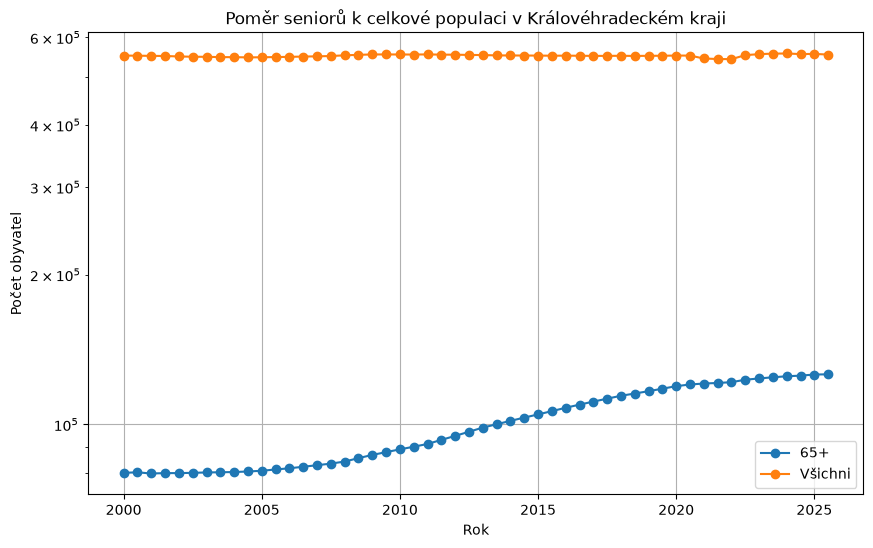

In [10]:
plot([(df_age_senior, '65+'), (df_age_all, 'Všichni')], 'Poměr seniorů k celkové populaci v Královéhradeckém kraji', 'Rok', 'Počet obyvatel')

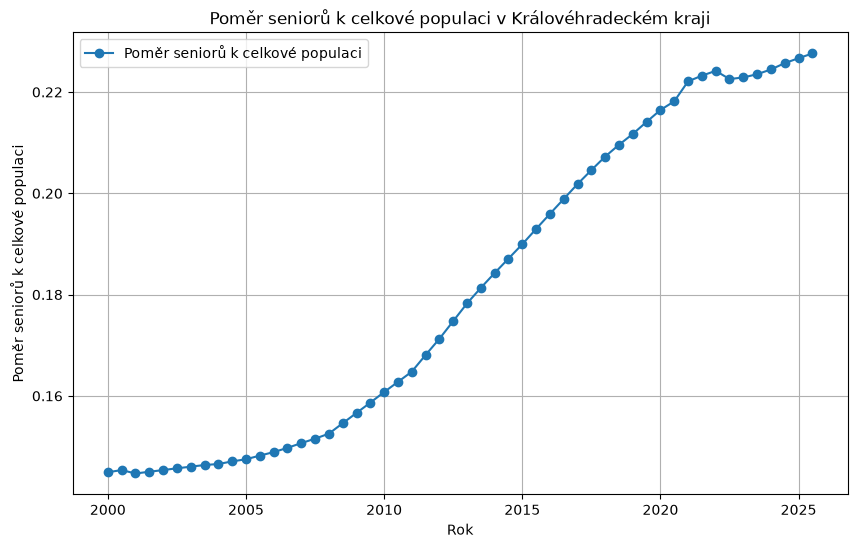

In [11]:
plot_simple([(df_age_ratio, 'Poměr seniorů k celkové populaci')], 'Poměr seniorů k celkové populaci v Královéhradeckém kraji', 'Rok', 'Poměr seniorů k celkové populaci')

## Suburbanizace

Následují testy se týkají suburbanizace Prahy a Brna. Zde budu využívat informace o změně obyvatelstva v obcích. Tato data lze najít na adrese [https://data.csu.gov.cz/datastat/data/VYBER/OBY02AT02?vSel=1](https://data.csu.gov.cz/datastat/data/VYBER/OBY02AT02?vSel=1). Dále pro přidání vazby mezi ID obcí a ID okresů využívám následující data: [https://apl2.czso.cz/iSMS/do_cis_export?kodcis=43&typdat=1&cisvaz=101_333&datpohl=11.07.2026&cisjaz=203&format=2](https://apl2.czso.cz/iSMS/do_cis_export?kodcis=43&typdat=1&cisvaz=101_333&datpohl=11.07.2026&cisjaz=203&format=2).

Budu dál používat následující kódy okresů:

- Praha-východ -- 40240
- Praha-západ -- 40258
- Brno-venkov -- 40720
- Beroun -- 40177

### Zpracování dat

In [12]:
with open("pocet_obyvatel.json") as f:
    data = f.read()
jstat_population = pyjstat.Dataset.read(data)
df_population = jstat_population.write('dataframe')
df_population_ids = jstat_population.write('dataframe', naming="id")

In [13]:
df_population.rename(columns={'Roky': 'year', 'Kraje a obce': 'town'}, inplace=True)
df_population.dropna(inplace=True)

# Používáme ID obcí a krajů místo názvů kvůli duplicitám
df_population["town"] = df_population_ids["UZ25"]

# Nastavení měření 1.7. jako o půl roku posunutý
df_population['year'] = df_population['year'].astype(float)
df_population.loc[df_population['Ukazatel'] == 'Počet obyvatel k 1. 7. (střední stav)', 'year'] += 0.5
df_population.drop(columns=['Ukazatel'], inplace=True)

df_population

,town,year,value
0,CZ010,2026.0,1407084.0
1,CZ010,2025.0,1397880.0
2,CZ010,2024.0,1384732.0
3,CZ010,2023.0,1357326.0
4,CZ010,2022.0,1275406.0
...,...,...,...
98329,584282,2004.5,3103.0
98330,584282,2003.5,3080.0
98331,584282,2002.5,3085.0
98332,584282,2001.5,3082.0


#### Mapování obcí a okresů

Níže si můžeme všimnout, že obce, které nás zajímají, jsou jednoznačně identifikovatelné svým názvem. To nám hraje celkem dost do karet, protože nám stačí identifikovat obce jen pomocí jeho názvu.



In [14]:
town_label_id_mapping = {}

towns_of_interest = ['Praha', 'Brno', 'Beroun', 'Králův Dvůr']

town_id_label_mapping = jstat_population['dimension']['UZ25']['category']['label']

for k, v in town_id_label_mapping.items():
    if v in towns_of_interest:
        if v in town_label_id_mapping:
            print(f"Warning: Duplicate town name '{v}' found. Overwriting previous entry.")
        town_label_id_mapping[v] = k

Teď stáhneme tabulku s vazbou mezi okresy a obcemi.

In [15]:
url_vazba = "https://apl2.czso.cz/iSMS/do_cis_export?kodcis=43&typdat=1&cisvaz=101_333&datpohl=11.07.2026&cisjaz=203&format=2"

df_mapping = pd.read_csv(url_vazba, sep=',')

df_mapping = df_mapping[['chodnota1', 'chodnota2']]
df_mapping.columns = ['kod_obce', 'kod_okresu']

df_mapping['kod_obce'] = df_mapping['kod_obce'].astype(str)
df_mapping['kod_okresu'] = df_mapping['kod_okresu'].astype(str)

display(df_mapping)

,kod_obce,kod_okresu
0,500011,40851
1,500020,40819
2,500046,40894
3,500062,40843
4,500071,40843
...,...,...
6253,599930,40894
6254,599948,40894
6255,599956,40894
6256,599964,40894


A nakonec provedeme merge dataframů, jeden s informaci o obyvatelstvu a jeden s informací o tom, jaká obec je v jakém okresu.

In [16]:
df = pd.merge(df_population, df_mapping, left_on='town', right_on='kod_obce', how='left')
df.drop(columns=['kod_obce'], inplace=True)

### Praha

Budeme testovat, zda v Praze probíhá suburbanizace. Hypotézy jsou následující:

- nulová $H_0$ -- neexistuje žádný monotónní trend u poměru počtu obyvatel Prahy-východ a Prahy-západ a počtu obyvatel Prahy
- a alternativní $H_1$ -- naopak monotónní trend existuje.

#### Příprava dat

In [17]:
prague_id = town_label_id_mapping['Praha']
df_prague = df[df['town'] == prague_id]
df_prague_grouped = df_prague.groupby('year')['value'].sum().reset_index()

# Vybereme okresy Praha-východ (40240) a Praha-západ (40258) jako předměstí Prahy
df_prague_suburb = df[df['kod_okresu'].isin(['40240', '40258'])]
df_prague_suburb_grouped = df_prague_suburb.groupby('year')['value'].sum().reset_index()

df_prague_ratio = pd.DataFrame({
    'year': df_prague_suburb_grouped['year'],
    'value': df_prague_suburb_grouped['value'] / df_prague_grouped['value']
})

#### Testování hypotézy

V proměnné `df_prague_ratio` máme teď uložený poměr lidí žijící v Praze-východ nebo v Praze-západ vůči lidem žijící v Praze. Jak si níže můžeme všimnout, test vyšel s $p \doteq 1{,}65 \cdot 10^{-5}$ s verdiktem, že existuje rostoucí trend, tedy nulovou hypotézu $H_0$ *zamítáme*. Pro znázornění dat nalezneme níže grafy.

In [18]:
test_hypothesis(df_prague_ratio)

Trend: increasing, p-value: 1.6468063906094343e-05, slope: 0.0024452196472265677


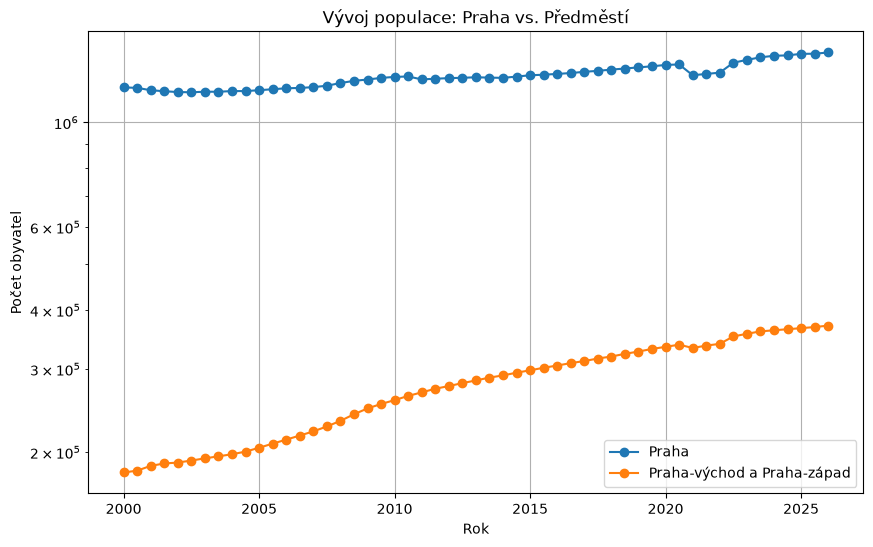

In [19]:
plot([(df_prague_grouped, 'Praha'), (df_prague_suburb_grouped, 'Praha-východ a Praha-západ')], 'Vývoj populace: Praha vs. Předměstí', 'Rok', 'Počet obyvatel')

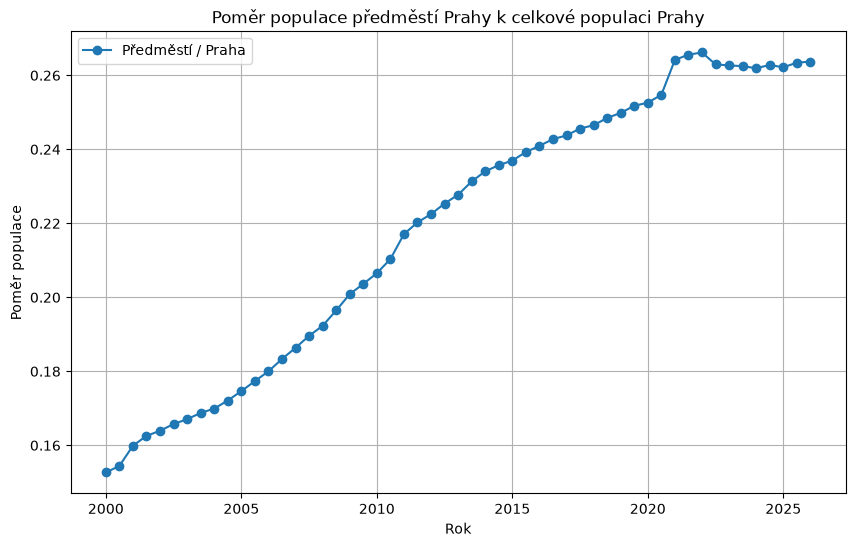

In [20]:
plot_simple([(df_prague_ratio, 'Předměstí / Praha')], 'Poměr populace předměstí Prahy k celkové populaci Prahy', 'Rok', 'Poměr populace')

### Brno

Budeme testovat, zda v Brně probíhá suburbanizace. Hypotézy jsou následující:

- nulová $H_0$ -- neexistuje žádný monotónní trend u poměru počtu obyvatel Brna-venkov a počtu obyvatel Brna
- a alternativní $H_1$ -- naopak monotónní trend existuje.

#### Příprava dat

In [21]:
brno_id = town_label_id_mapping['Brno']

df_brno = df[df['town'] == brno_id]
df_brno_grouped = df_brno.groupby('year')['value'].sum().reset_index()

# Vybereme okres Brno-venkov (40720) jako předměstí Brna
df_brno_suburb = df[df['kod_okresu'] == '40720']
df_brno_suburb_grouped = df_brno_suburb.groupby('year')['value'].sum().reset_index()

df_brno_ratio = pd.DataFrame({
    'year': df_brno_suburb_grouped['year'],
    'value': df_brno_suburb_grouped['value'] / df_brno_grouped['value']
})

#### Testování hypotézy

V proměnné `df_brno_ratio` máme teď uložený poměr lidí žijící v Brně-venkov vůči lidem žijící v Brně. Níže je vidět, test vyšel s $p \doteq 0{,}013 \%$ s verdiktem, že existuje rostoucí trend, tedy nulovou hypotézu $H_0$ *zamítáme*. Pro znázornění zase nalezneme graf níže.

In [22]:
test_hypothesis(df_brno_ratio)

Trend: increasing, p-value: 0.00013173190037574223, slope: 0.0025192282151194558


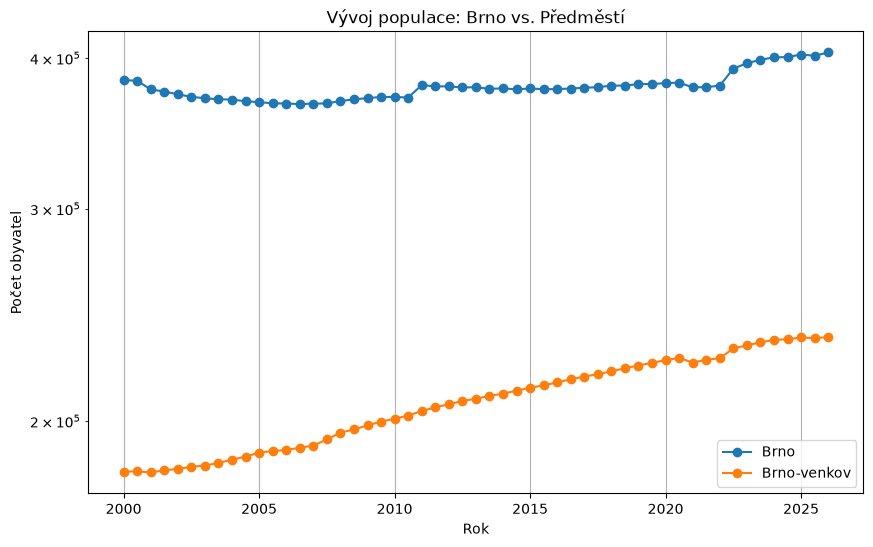

In [23]:
plot([(df_brno_grouped, 'Brno'), (df_brno_suburb_grouped, 'Brno-venkov')], 'Vývoj populace: Brno vs. Předměstí', 'Rok', 'Počet obyvatel')

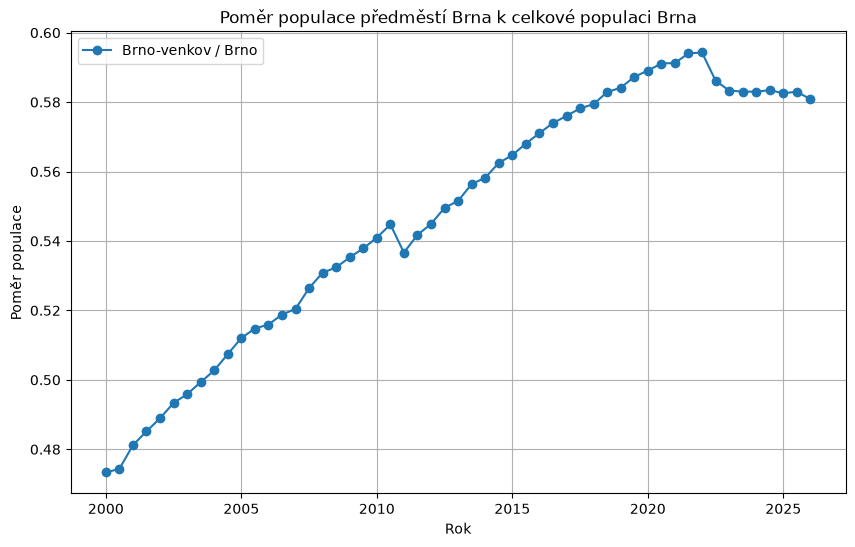

In [24]:
plot_simple([(df_brno_ratio, 'Brno-venkov / Brno')], 'Poměr populace předměstí Brna k celkové populaci Brna', 'Rok', 'Poměr populace')

## Růst obyvatel Berouna a Králova Dvora + suburbanizace

Teď se podíváme na růst obyvatelstva Berouna a Králova Dvora. Tato dvě města prakticky tvoří souměstí (dříve dokonce Králův Dvůr byl součástí Berouna), budu tedy teď testovat následující hypotézy:

1. Růst obyvatel Berouna
    - nulová hypotéza -- neexistuje žádný monotónní trend o změně počtu obyvatel Berouna
    - alternativní hypotéza -- existuje monotónní trend o změně počtu obyvatel Berouna
2. Růst obyvatel Králova Dvora -- hypotézy budou totožné jako u Berouna, jen místo Berouna budeme mít Králův Dvůr
3. Suburbanizace v okolí Berouna a Králova Dvora
    - nulová hypotéza -- neexistuje žádný monotónní trend o poměru počtu obyvatel okolních obcí souměstí Beroun a Králův Dvůr ku počtu obyvatel Berouna a Králova Dvora 
    - alternativní hypotéza -- naopak existuje monotónní trend o poměru počtu obyvatel okolních obcí souměstí Beroun a Králův Dvůr ku počtu obyvatel Berouna a Králova Dvora



### Získání ID zvolených okolních obcí

Díky bohu v okrese Beroun není žádná dvojice obcí, které by se jmenovaly stejně. Díky tomu můžeme získávat ID obcí jen z názvů obcí. Názvy zvolených okolních obcí lze najít v proměnné `beroun_region_towns_of_interest`.

In [25]:
beroun_region_id = "40177" # ID okresu Beroun v datasetu
beroun_id_label_mapping = {}

for town_id in df_mapping[df_mapping['kod_okresu'] == beroun_region_id]['kod_obce']:
    if town_id in town_id_label_mapping:
        if town_id in beroun_id_label_mapping:
            print(f"Warning: Duplicate town ID '{town_id}' found in Beroun region. Overwriting previous entry.")
        beroun_id_label_mapping[town_id] = town_id_label_mapping[town_id]

beroun_region_towns_of_interest = ['Hýskov', 'Tetín', 'Vráž', 'Trubín', 'Trubská', 'Zdice', 'Nižbor', 'Chyňava', 'Svatý Jan pod Skalou', 'Koněprusy', 'Tmaň', 'Loděnice']
beroun_region_town_ids = [k for k, v in beroun_id_label_mapping.items() if v in beroun_region_towns_of_interest]

### Zpracování dat

In [26]:
beroun_id = town_label_id_mapping['Beroun']
df_beroun = df[df['town'] == beroun_id]
df_beroun_grouped = df_beroun.groupby('year')['value'].sum().reset_index()

kraluv_dvur_id = town_label_id_mapping['Králův Dvůr']
df_kraluv_dvur = df[df['town'] == kraluv_dvur_id]
df_kraluv_dvur_grouped = df_kraluv_dvur.groupby('year')['value'].sum().reset_index()



In [27]:
df_beroun_region_towns = df[df['town'].isin(beroun_region_town_ids)]
df_beroun_region_towns_grouped = df_beroun_region_towns.groupby('year')['value'].sum().reset_index()

df_beroun_ratio = pd.DataFrame({
    'year': df_beroun_region_towns_grouped['year'],
    'value': df_beroun_region_towns_grouped['value'] / (df_beroun_grouped['value'] + df_kraluv_dvur_grouped['value'])
})

### Testování hypotéz

V proměnné `df_beroun_grouped` máme teď uložené měření počtu obyvatel Berouna, v proměnné `df_kraluv_dvur_grouped` zase měření počtu obyvatel Králova Dvora a v proměnné `df_beroun_ratio` poměr počtu obyvatel okolí vůči počtu obyvatel Berouna a Králova Dvora. Testy vyšly následovně:

1. Změna obyvatel Berouna -- $p \doteq 1{,}19 \cdot 10^{-10}$ s verdiktem, že počet obyvatel roste, tedy nulovou hypotézu *zamítáme*
2. Změna obyvatel Králova Dvora -- $p \doteq 2{,}699 \cdot 10^{-5}$ s verdiktem, že počet obyvatel roste, tedy nulovou hypotézu *zamítáme*
3. Poměr obyvatel okolí a Berouna + Králova Dvora -- $p \doteq 90{,}6 \%$, tedy nulovou hypotézu *nezamítáme*

Níže jsou zase grafy pro představu. Hlavně na grafu poměru počtu obyvatel okolí a Berouna + Králova Dvora je vidět důvod, proč $p$-hodnota vyšla tak vysoká.

In [28]:
test_hypothesis(df_beroun_grouped)
test_hypothesis(df_kraluv_dvur_grouped)
test_hypothesis(df_beroun_ratio)

Trend: increasing, p-value: 1.1942558053590346e-10, slope: 67.25952380952381
Trend: increasing, p-value: 2.6990343408250794e-05, slope: 116.02272727272728
Trend: no trend, p-value: 0.906461150636894, slope: -6.463470600339373e-05


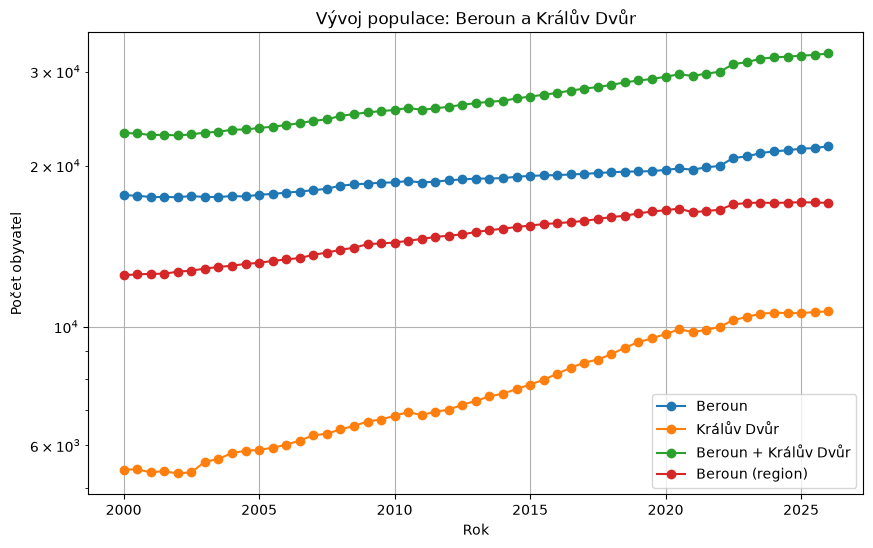

In [29]:
df_beroun_kraluv_dvur = pd.merge(df_beroun_grouped, df_kraluv_dvur_grouped, on='year', suffixes=('_beroun', '_kraluv_dvur'))
df_beroun_kraluv_dvur['value'] = df_beroun_kraluv_dvur['value_beroun'] + df_beroun_kraluv_dvur['value_kraluv_dvur']

plot([(df_beroun_grouped, 'Beroun'), (df_kraluv_dvur_grouped, 'Králův Dvůr'), (df_beroun_kraluv_dvur, 'Beroun + Králův Dvůr'), (df_beroun_region_towns_grouped, 'Beroun (region)')], 'Vývoj populace: Beroun a Králův Dvůr', 'Rok', 'Počet obyvatel')

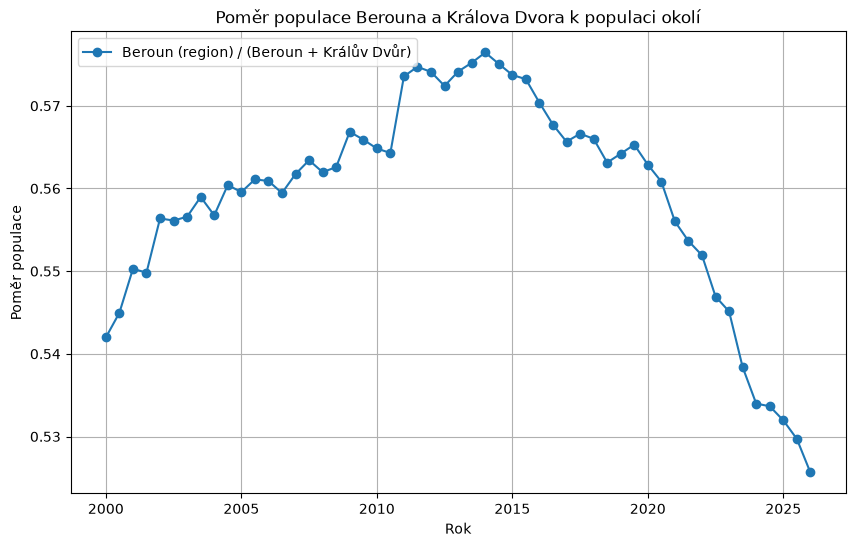

In [30]:
plot_simple([(df_beroun_ratio, 'Beroun (region) / (Beroun + Králův Dvůr)')], 'Poměr populace Berouna a Králova Dvora k populaci okolí', 'Rok', 'Poměr populace')